In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [3]:
import joblib


In [4]:
pd.set_option('display.max_columns', None)
%matplotlib inline

In [239]:
df= pd.read_csv(r"C:\Users\LENOVO\Desktop\project_ml_retail\data\processed\df_clean_start.csv")
print("shape:",df.shape)
df.head()

shape: (4372, 52)


,CustomerID,Recency,Frequency,MonetaryTotal,MonetaryAvg,MonetaryStd,MonetaryMin,MonetaryMax,TotalQuantity,AvgQuantityPerTransaction,MinQuantity,MaxQuantity,CustomerTenureDays,FirstPurchaseDaysAgo,PreferredDayOfWeek,PreferredHour,PreferredMonth,WeekendPurchaseRatio,AvgDaysBetweenPurchases,UniqueProducts,UniqueDescriptions,AvgProductsPerTransaction,UniqueCountries,NegativeQuantityCount,ZeroPriceCount,CancelledTransactions,ReturnRatio,TotalTransactions,UniqueInvoices,AvgLinesPerInvoice,Age,RegistrationDate,NewsletterSubscribed,LastLoginIP,SupportTicketsCount,SatisfactionScore,RFMSegment,AgeCategory,SpendingCategory,CustomerType,FavoriteSeason,PreferredTimeOfDay,Region,LoyaltyLevel,ChurnRiskCategory,WeekendPreference,BasketSizeCategory,ProductDiversity,Gender,AccountStatus,Country,Churn
0,17850,302,35,5288.63,16.950737,13.603662,-30.60,107.25,1693,5.426282,-12,12,71,374,3,9,12,0.000000,0.221865,24,25,0.685714,1,15,0,15,0.048077,312,35,8.914286,NaN,17/07/10,Yes,59.252.219.201,1.0,4.0,Fidèles,Inconnu,VIP,Perdu,Hiver,Matin,UK,Jeune,Critique,Inconnu,Moyen,Explorateur,Unknown,Active,United Kingdom,1
1,13047,32,18,3079.10,15.709694,11.684769,-15.00,68.00,1355,6.913265,-3,32,342,374,2,13,10,0.168367,1.717949,106,106,5.888889,1,24,0,24,0.122449,196,18,10.888889,NaN,2010-10-04,Yes,77.255.247.14,3.0,4.0,Champions,Inconnu,VIP,Régulier,Automne,Midi,UK,Établi,Moyen,Semaine,Moyen,Explorateur,M,Active,United Kingdom,0
2,12583,3,18,7187.34,28.634821,23.150132,-60.84,132.80,5009,19.956175,-36,360,370,374,4,12,11,0.055777,1.456000,115,117,6.388889,1,4,0,4,0.015936,251,18,13.944444,46.0,12/09/2009,Yes,51.139.78.80,2.0,5.0,Champions,45-54,VIP,Hyperactif,Automne,Midi,Europe continentale,Ancien,Faible,Semaine,Grand,Explorateur,Unknown,Active,France,0
3,13748,96,5,948.25,33.866071,42.953119,9.36,204.00,439,15.678571,1,80,278,374,0,9,9,0.000000,10.259259,24,24,4.800000,1,0,0,0,0.000000,28,5,5.600000,32.0,28/01/10,Yes,10.212.80.124,2.0,2.0,Potentiels,25-34,High,Nouveau,Automne,Matin,UK,Établi,Critique,Inconnu,Grand,Explorateur,Unknown,Active,United Kingdom,1
4,15100,330,6,635.10,105.850000,215.986263,-131.40,350.40,58,9.666667,-12,32,43,374,2,9,12,0.000000,8.200000,1,1,0.166667,1,3,0,3,0.500000,6,6,1.000000,NaN,2009-12-10,Yes,186.34.121.80,2.0,1.0,Potentiels,Inconnu,High,Perdu,Hiver,Matin,UK,Jeune,Critique,Inconnu,Moyen,Spécialisé,M,Active,United Kingdom,1


In [240]:
# Colonnes numériques
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numériques:", numeric_cols)

Numériques: ['CustomerID', 'Recency', 'Frequency', 'MonetaryTotal', 'MonetaryAvg', 'MonetaryStd', 'MonetaryMin', 'MonetaryMax', 'TotalQuantity', 'AvgQuantityPerTransaction', 'MinQuantity', 'MaxQuantity', 'CustomerTenureDays', 'FirstPurchaseDaysAgo', 'PreferredDayOfWeek', 'PreferredHour', 'PreferredMonth', 'WeekendPurchaseRatio', 'AvgDaysBetweenPurchases', 'UniqueProducts', 'UniqueDescriptions', 'AvgProductsPerTransaction', 'UniqueCountries', 'NegativeQuantityCount', 'ZeroPriceCount', 'CancelledTransactions', 'ReturnRatio', 'TotalTransactions', 'UniqueInvoices', 'AvgLinesPerInvoice', 'Age', 'SupportTicketsCount', 'SatisfactionScore', 'Churn']


In [241]:
# Colonnes catégorielles (object)
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Catégorielles:", categorical_cols)

Catégorielles: ['RegistrationDate', 'NewsletterSubscribed', 'LastLoginIP', 'RFMSegment', 'AgeCategory', 'SpendingCategory', 'CustomerType', 'FavoriteSeason', 'PreferredTimeOfDay', 'Region', 'LoyaltyLevel', 'ChurnRiskCategory', 'WeekendPreference', 'BasketSizeCategory', 'ProductDiversity', 'Gender', 'AccountStatus', 'Country']


In [242]:
# Vue d'ensemble
print("Shape:", df.shape)
print("\nValeurs manquantes :")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\nDoublons :", df.duplicated().sum())
print("\nTypes :")
print(df.dtypes.value_counts())

Shape: (4372, 52)

Valeurs manquantes :
AvgDaysBetweenPurchases      79
Age                        1311
dtype: int64

Doublons : 0

Types :
int64      20
object     18
float64    14
Name: count, dtype: int64


🔢 Étape 2 — Conversion des colonnes numériques stockées en object-->numerique




In [243]:
cols_to_convert = [
    'MonetaryTotal', 'MonetaryAvg', 'MonetaryStd', 'MonetaryMin', 'MonetaryMax',
    'AvgQuantityPerTransaction', 'AvgDaysBetweenPurchases',
    'AvgProductsPerTransaction', 'AvgLinesPerInvoice'
]

for col in cols_to_convert:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print("Conversion OK")
print(df[cols_to_convert].dtypes)

Conversion OK
MonetaryTotal                float64
MonetaryAvg                  float64
MonetaryStd                  float64
MonetaryMin                  float64
MonetaryMax                  float64
AvgQuantityPerTransaction    float64
AvgDaysBetweenPurchases      float64
AvgProductsPerTransaction    float64
AvgLinesPerInvoice           float64
dtype: object


In [244]:
print(df['ReturnRatio'].dtype)        # → float64
print(df['WeekendPurchaseRatio'].dtype) # → float64

float64
float64


🚨 Étape 3 — Correction des valeurs aberrantes par NaN


In [245]:
# SupportTicketsCount : -1 et 999 sont des codes erreur
df['SupportTicketsCount'] = df['SupportTicketsCount'].replace([-1, 999], np.nan)

# SatisfactionScore : -1, 0, 99 sont invalides (échelle 1-5)
df['SatisfactionScore'] = df['SatisfactionScore'].apply(
    lambda x: np.nan if x in [-1, 0, 99] else x
)

print("Aberrantes corrigées")
print(df[['SupportTicketsCount', 'SatisfactionScore']].describe())

Aberrantes corrigées
       SupportTicketsCount  SatisfactionScore
count          4242.000000        4023.000000
mean              1.967468           3.013671
std               1.402116           1.431882
min               0.000000           1.000000
25%               1.000000           2.000000
50%               2.000000           3.000000
75%               3.000000           4.000000
max               9.000000           5.000000


📅 Étape 4 — Parsing de RegistrationDate


In [246]:
df['RegistrationDate'] = pd.to_datetime(df['RegistrationDate'], dayfirst=True, errors='coerce')

df['RegYear']    = df['RegistrationDate'].dt.year
df['RegMonth']   = df['RegistrationDate'].dt.month


df.drop(columns=['RegistrationDate'], inplace=True)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10524\2792365071.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['RegistrationDate'] = pd.to_datetime(df['RegistrationDate'], dayfirst=True, errors='coerce')


In [247]:
print(df.columns)

Index(['CustomerID', 'Recency', 'Frequency', 'MonetaryTotal', 'MonetaryAvg',
       'MonetaryStd', 'MonetaryMin', 'MonetaryMax', 'TotalQuantity',
       'AvgQuantityPerTransaction', 'MinQuantity', 'MaxQuantity',
       'CustomerTenureDays', 'FirstPurchaseDaysAgo', 'PreferredDayOfWeek',
       'PreferredHour', 'PreferredMonth', 'WeekendPurchaseRatio',
       'AvgDaysBetweenPurchases', 'UniqueProducts', 'UniqueDescriptions',
       'AvgProductsPerTransaction', 'UniqueCountries', 'NegativeQuantityCount',
       'ZeroPriceCount', 'CancelledTransactions', 'ReturnRatio',
       'TotalTransactions', 'UniqueInvoices', 'AvgLinesPerInvoice', 'Age',
       'NewsletterSubscribed', 'LastLoginIP', 'SupportTicketsCount',
       'SatisfactionScore', 'RFMSegment', 'AgeCategory', 'SpendingCategory',
       'CustomerType', 'FavoriteSeason', 'PreferredTimeOfDay', 'Region',
       'LoyaltyLevel', 'ChurnRiskCategory', 'WeekendPreference',
       'BasketSizeCategory', 'ProductDiversity', 'Gender', 'AccountSt

In [248]:
df[['RegYear', 'RegMonth']]

,RegYear,RegMonth
0,2010,7
1,2010,10
2,2009,9
3,2010,1
4,2009,12
...,...,...
4367,2011,12
4368,2011,9
4369,2011,12
4370,2011,7


🌐 Étape 5 — Feature engineering sur LastLoginIP


In [249]:
df['LastLoginIP']

0        59.252.219.201
1         77.255.247.14
2          51.139.78.80
3         10.212.80.124
4         186.34.121.80
             ...       
4367      28.217.44.198
4368     190.170.94.224
4369       22.250.38.14
4370    226.235.111.122
4371     154.168.54.141
Name: LastLoginIP, Length: 4372, dtype: object

In [250]:
import geoip2.database


reader = geoip2.database.Reader(r'C:\Users\LENOVO\Desktop\project_ml_retail\GeoLite2-Country_20260327\GeoLite2-Country_20260327\GeoLite2-Country.mmdb')

def get_country(ip):
    if pd.isna(ip) or not isinstance(ip, str):
        return np.nan
    try:
        response = reader.country(ip)
        return response.country.name
    except:
        return np.nan

In [251]:
df['Country'] 

0       United Kingdom
1       United Kingdom
2               France
3       United Kingdom
4       United Kingdom
             ...      
4367    United Kingdom
4368    United Kingdom
4369    United Kingdom
4370    United Kingdom
4371           Germany
Name: Country, Length: 4372, dtype: object

In [252]:
df['GeoIP'] = df['LastLoginIP'].apply(get_country)

In [253]:
df['GeoIP']

0               China
1              Poland
2       United States
3                 NaN
4               Chile
            ...      
4367    United States
4368        Venezuela
4369    United States
4370              NaN
4371            Ghana
Name: GeoIP, Length: 4372, dtype: object

CREATION d'une nouvelle feature "country mismatch"


In [254]:
df['CountryMismatch'] = np.where(
    df['Country'].isna() | df['GeoIP'].isna(),
    np.nan,
    (df['Country'] != df['GeoIP']).astype(int)
) #diff 1, kifkif 0

In [255]:
df['CountryMismatch']

0       1.0
1       1.0
2       1.0
3       NaN
4       1.0
       ... 
4367    1.0
4368    1.0
4369    1.0
4370    NaN
4371    1.0
Name: CountryMismatch, Length: 4372, dtype: float64

In [256]:
df = df.drop(columns=["LastLoginIP"])

🗑️ Étape 6 — Suppression des colonnes inutiles


In [257]:
cols_to_drop = []

# NewsletterSubscribed : variance nulle (toujours "Yes")
if 'NewsletterSubscribed' in df.columns:
    cols_to_drop.append('NewsletterSubscribed')

# CustomerID : identifiant, pas une feature prédictive
if 'CustomerID' in df.columns:
    cols_to_drop.append('CustomerID')
    
#Raison ethique faut pas differencier le marketing selon le genre
if 'Gender' in df.columns:
    cols_to_drop.append('Gender')


df.drop(columns=cols_to_drop, inplace=True)
print(f"Colonnes supprimées : {cols_to_drop}")

Colonnes supprimées : ['NewsletterSubscribed', 'CustomerID', 'Gender']


✅ 1. Trop de valeurs manquantes (>50%)

In [258]:
missing_ratio = df.isna().mean()

# features with >50% missing
high_missing = missing_ratio[missing_ratio > 0.5]

print(high_missing)

Series([], dtype: float64)


⚙️ Étape 7 — Feature engineering


In [259]:
df['MonetaryPerDay']  = df['MonetaryTotal'] / (df['CustomerTenureDays'] + 1)
df['AvgBasketValue']  = df['MonetaryTotal'] / (df['Frequency'] + 1)
df['TenureRatio']     = df['Recency'] / (df['CustomerTenureDays'] + 1)
df['CancelRate']      = df['CancelledTransactions'] / (df['TotalTransactions'] + 1)
df['ProductsPerTrans']= df['UniqueProducts'] / (df['TotalTransactions'] + 1)

print("5 nouvelles features créées ✓")
print(df[['MonetaryPerDay','AvgBasketValue','TenureRatio','CancelRate','ProductsPerTrans']].head())

5 nouvelles features créées ✓
   MonetaryPerDay  AvgBasketValue  TenureRatio  CancelRate  ProductsPerTrans
0       73.453194      146.906389     4.194444    0.047923          0.076677
1        8.976968      162.057895     0.093294    0.121827          0.538071
2       19.372884      378.281053     0.008086    0.015873          0.456349
3        3.398746      158.041667     0.344086    0.000000          0.827586
4       14.434091       90.728571     7.500000    0.428571          0.142857


In [260]:
#dropping : recency, 'CustomerTenureDays,'CancelledTransactions,'UniqueProducts'
df = df.drop(columns=[
    'Recency',
    'CustomerTenureDays',
    'CancelledTransactions',
    'UniqueProducts'
])

In [261]:
df = df.drop(columns=['RFMSegment'])

In [221]:
#tenure ratio : how recently this customer stopped buying so its a definition of churn
#RFMSegment (dormant=churned)

In [262]:
print("Shape final :", df.shape)
print("\nValeurs manquantes restantes :")
missing = df.isnull().sum()
print(missing[missing > 0])

print("\nTypes finaux :")
print(df.dtypes.value_counts())



Shape final : (4372, 51)

Valeurs manquantes restantes :
AvgDaysBetweenPurchases      79
Age                        1311
SupportTicketsCount         130
SatisfactionScore           349
GeoIP                       637
CountryMismatch             637
dtype: int64

Types finaux :
float64    20
int64      15
object     14
int32       2
Name: count, dtype: int64


In [263]:
# Colonnes numériques
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numériques:", numeric_cols)

Numériques: ['Frequency', 'MonetaryTotal', 'MonetaryAvg', 'MonetaryStd', 'MonetaryMin', 'MonetaryMax', 'TotalQuantity', 'AvgQuantityPerTransaction', 'MinQuantity', 'MaxQuantity', 'FirstPurchaseDaysAgo', 'PreferredDayOfWeek', 'PreferredHour', 'PreferredMonth', 'WeekendPurchaseRatio', 'AvgDaysBetweenPurchases', 'UniqueDescriptions', 'AvgProductsPerTransaction', 'UniqueCountries', 'NegativeQuantityCount', 'ZeroPriceCount', 'ReturnRatio', 'TotalTransactions', 'UniqueInvoices', 'AvgLinesPerInvoice', 'Age', 'SupportTicketsCount', 'SatisfactionScore', 'Churn', 'RegYear', 'RegMonth', 'CountryMismatch', 'MonetaryPerDay', 'AvgBasketValue', 'TenureRatio', 'CancelRate', 'ProductsPerTrans']


In [264]:
print("shape:",df.shape)
df.head()

shape: (4372, 51)


,Frequency,MonetaryTotal,MonetaryAvg,MonetaryStd,MonetaryMin,MonetaryMax,TotalQuantity,AvgQuantityPerTransaction,MinQuantity,MaxQuantity,FirstPurchaseDaysAgo,PreferredDayOfWeek,PreferredHour,PreferredMonth,WeekendPurchaseRatio,AvgDaysBetweenPurchases,UniqueDescriptions,AvgProductsPerTransaction,UniqueCountries,NegativeQuantityCount,ZeroPriceCount,ReturnRatio,TotalTransactions,UniqueInvoices,AvgLinesPerInvoice,Age,SupportTicketsCount,SatisfactionScore,AgeCategory,SpendingCategory,CustomerType,FavoriteSeason,PreferredTimeOfDay,Region,LoyaltyLevel,ChurnRiskCategory,WeekendPreference,BasketSizeCategory,ProductDiversity,AccountStatus,Country,Churn,RegYear,RegMonth,GeoIP,CountryMismatch,MonetaryPerDay,AvgBasketValue,TenureRatio,CancelRate,ProductsPerTrans
0,35,5288.63,16.950737,13.603662,-30.60,107.25,1693,5.426282,-12,12,374,3,9,12,0.000000,0.221865,25,0.685714,1,15,0,0.048077,312,35,8.914286,NaN,1.0,4.0,Inconnu,VIP,Perdu,Hiver,Matin,UK,Jeune,Critique,Inconnu,Moyen,Explorateur,Active,United Kingdom,1,2010,7,China,1.0,73.453194,146.906389,4.194444,0.047923,0.076677
1,18,3079.10,15.709694,11.684769,-15.00,68.00,1355,6.913265,-3,32,374,2,13,10,0.168367,1.717949,106,5.888889,1,24,0,0.122449,196,18,10.888889,NaN,3.0,4.0,Inconnu,VIP,Régulier,Automne,Midi,UK,Établi,Moyen,Semaine,Moyen,Explorateur,Active,United Kingdom,0,2010,10,Poland,1.0,8.976968,162.057895,0.093294,0.121827,0.538071
2,18,7187.34,28.634821,23.150132,-60.84,132.80,5009,19.956175,-36,360,374,4,12,11,0.055777,1.456000,117,6.388889,1,4,0,0.015936,251,18,13.944444,46.0,2.0,5.0,45-54,VIP,Hyperactif,Automne,Midi,Europe continentale,Ancien,Faible,Semaine,Grand,Explorateur,Active,France,0,2009,9,United States,1.0,19.372884,378.281053,0.008086,0.015873,0.456349
3,5,948.25,33.866071,42.953119,9.36,204.00,439,15.678571,1,80,374,0,9,9,0.000000,10.259259,24,4.800000,1,0,0,0.000000,28,5,5.600000,32.0,2.0,2.0,25-34,High,Nouveau,Automne,Matin,UK,Établi,Critique,Inconnu,Grand,Explorateur,Active,United Kingdom,1,2010,1,NaN,NaN,3.398746,158.041667,0.344086,0.000000,0.827586
4,6,635.10,105.850000,215.986263,-131.40,350.40,58,9.666667,-12,32,374,2,9,12,0.000000,8.200000,1,0.166667,1,3,0,0.500000,6,6,1.000000,NaN,2.0,1.0,Inconnu,High,Perdu,Hiver,Matin,UK,Jeune,Critique,Inconnu,Moyen,Spécialisé,Active,United Kingdom,1,2009,12,Chile,1.0,14.434091,90.728571,7.500000,0.428571,0.142857


In [265]:
#critical leakage feature:
#ChurnRiskCategory,CustomerTye( perdu),accountstatues(suspended yaani churned)
df = df.drop(columns=[
    'ChurnRiskCategory',
    'CustomerType',
    'AccountStatus',
])

In [266]:
print("shape:",df.shape)
df.head()


shape: (4372, 48)


,Frequency,MonetaryTotal,MonetaryAvg,MonetaryStd,MonetaryMin,MonetaryMax,TotalQuantity,AvgQuantityPerTransaction,MinQuantity,MaxQuantity,FirstPurchaseDaysAgo,PreferredDayOfWeek,PreferredHour,PreferredMonth,WeekendPurchaseRatio,AvgDaysBetweenPurchases,UniqueDescriptions,AvgProductsPerTransaction,UniqueCountries,NegativeQuantityCount,ZeroPriceCount,ReturnRatio,TotalTransactions,UniqueInvoices,AvgLinesPerInvoice,Age,SupportTicketsCount,SatisfactionScore,AgeCategory,SpendingCategory,FavoriteSeason,PreferredTimeOfDay,Region,LoyaltyLevel,WeekendPreference,BasketSizeCategory,ProductDiversity,Country,Churn,RegYear,RegMonth,GeoIP,CountryMismatch,MonetaryPerDay,AvgBasketValue,TenureRatio,CancelRate,ProductsPerTrans
0,35,5288.63,16.950737,13.603662,-30.60,107.25,1693,5.426282,-12,12,374,3,9,12,0.000000,0.221865,25,0.685714,1,15,0,0.048077,312,35,8.914286,NaN,1.0,4.0,Inconnu,VIP,Hiver,Matin,UK,Jeune,Inconnu,Moyen,Explorateur,United Kingdom,1,2010,7,China,1.0,73.453194,146.906389,4.194444,0.047923,0.076677
1,18,3079.10,15.709694,11.684769,-15.00,68.00,1355,6.913265,-3,32,374,2,13,10,0.168367,1.717949,106,5.888889,1,24,0,0.122449,196,18,10.888889,NaN,3.0,4.0,Inconnu,VIP,Automne,Midi,UK,Établi,Semaine,Moyen,Explorateur,United Kingdom,0,2010,10,Poland,1.0,8.976968,162.057895,0.093294,0.121827,0.538071
2,18,7187.34,28.634821,23.150132,-60.84,132.80,5009,19.956175,-36,360,374,4,12,11,0.055777,1.456000,117,6.388889,1,4,0,0.015936,251,18,13.944444,46.0,2.0,5.0,45-54,VIP,Automne,Midi,Europe continentale,Ancien,Semaine,Grand,Explorateur,France,0,2009,9,United States,1.0,19.372884,378.281053,0.008086,0.015873,0.456349
3,5,948.25,33.866071,42.953119,9.36,204.00,439,15.678571,1,80,374,0,9,9,0.000000,10.259259,24,4.800000,1,0,0,0.000000,28,5,5.600000,32.0,2.0,2.0,25-34,High,Automne,Matin,UK,Établi,Inconnu,Grand,Explorateur,United Kingdom,1,2010,1,NaN,NaN,3.398746,158.041667,0.344086,0.000000,0.827586
4,6,635.10,105.850000,215.986263,-131.40,350.40,58,9.666667,-12,32,374,2,9,12,0.000000,8.200000,1,0.166667,1,3,0,0.500000,6,6,1.000000,NaN,2.0,1.0,Inconnu,High,Hiver,Matin,UK,Jeune,Inconnu,Moyen,Spécialisé,United Kingdom,1,2009,12,Chile,1.0,14.434091,90.728571,7.500000,0.428571,0.142857


In [267]:
df.to_csv(r"C:\Users\LENOVO\Desktop\project_ml_retail\data\processed\df_processed.csv", index=False)

Sauvegarder data/processed/df_processed

prochaines etapes:
diviser en test/train
imputation,scaler ,encodage,equilibrage,

In [5]:
df = pd.read_csv(r"C:\Users\LENOVO\Desktop\project_ml_retail\data\processed\df_processed.csv")
print("Shape:", df.shape)

Shape: (4372, 48)


In [6]:
# ── 2. Define target & features ────────────────────────────────────────────────
TARGET = "Churn"   # ← change to your actual target column name

X = df.drop(columns=[TARGET])
y = df[TARGET]

print("X shape:", X.shape)
print("y value counts:\n", y.value_counts())

X shape: (4372, 47)
y value counts:
 Churn
0    2918
1    1454
Name: count, dtype: int64


In [7]:
# ── 3. Train / Test split (stratified) ────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # important for imbalanced classes
)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"\ny_train distribution:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"\ny_test  distribution:\n{y_test.value_counts(normalize=True).round(3)}")

Train: (3497, 47)  |  Test: (875, 47)

y_train distribution:
Churn
0    0.667
1    0.333
Name: proportion, dtype: float64

y_test  distribution:
Churn
0    0.667
1    0.333
Name: proportion, dtype: float64


In [8]:
# ── 4. Save splits ─────────────────────────────────────────────────────────────
import os
output_dir = r"C:\Users\LENOVO\Desktop\project_ml_retail\data\train_test\tree"
os.makedirs(output_dir, exist_ok=True)

X_train.to_csv(os.path.join(output_dir, "X_train.csv"), index=False)
X_test.to_csv(os.path.join(output_dir,  "X_test.csv"),  index=False)
y_train.to_csv(os.path.join(output_dir, "y_train.csv"), index=False)
y_test.to_csv(os.path.join(output_dir,  "y_test.csv"),  index=False)

print("Splits saved ✓")

Splits saved ✓


imputation

Median for skewed features (MonetaryTotal, MonetaryAvg, Recency, etc.) — you have negative values and outliers so median is safer than mean

In [9]:
train_num = X_train.select_dtypes(include="number").columns.tolist()
print(train_num)

['Frequency', 'MonetaryTotal', 'MonetaryAvg', 'MonetaryStd', 'MonetaryMin', 'MonetaryMax', 'TotalQuantity', 'AvgQuantityPerTransaction', 'MinQuantity', 'MaxQuantity', 'FirstPurchaseDaysAgo', 'PreferredDayOfWeek', 'PreferredHour', 'PreferredMonth', 'WeekendPurchaseRatio', 'AvgDaysBetweenPurchases', 'UniqueDescriptions', 'AvgProductsPerTransaction', 'UniqueCountries', 'NegativeQuantityCount', 'ZeroPriceCount', 'ReturnRatio', 'TotalTransactions', 'UniqueInvoices', 'AvgLinesPerInvoice', 'Age', 'SupportTicketsCount', 'SatisfactionScore', 'RegYear', 'RegMonth', 'CountryMismatch', 'MonetaryPerDay', 'AvgBasketValue', 'TenureRatio', 'CancelRate', 'ProductsPerTrans']


In [10]:
cols_with_nan = X_train.columns[X_train.isnull().any()]
print(cols_with_nan)
X_train[cols_with_nan]

Index(['AvgDaysBetweenPurchases', 'Age', 'SupportTicketsCount',
       'SatisfactionScore', 'GeoIP', 'CountryMismatch'],
      dtype='object')


,AvgDaysBetweenPurchases,Age,SupportTicketsCount,SatisfactionScore,GeoIP,CountryMismatch
380,3.632653,49.0,2.0,4.0,United States,1.0
2472,0.000000,53.0,3.0,2.0,Saudi Arabia,1.0
1961,4.071429,78.0,3.0,2.0,China,1.0
2029,2.612500,NaN,2.0,4.0,China,1.0
1384,2.294643,40.0,1.0,1.0,Japan,1.0
...,...,...,...,...,...,...
2564,0.000000,56.0,0.0,2.0,United States,1.0
692,0.693750,33.0,4.0,2.0,Canada,1.0
2302,1.713178,29.0,1.0,5.0,NaN,NaN
515,4.610390,19.0,0.0,2.0,United States,1.0


In [11]:
# ── 2. Median imputation on specific columns ───────────────────────────────────
cols_median = ['AvgDaysBetweenPurchases', 'SupportTicketsCount', 
               'SatisfactionScore']

imputer_median = SimpleImputer(strategy='median')

# Fit on X_train ONLY, transform both
X_train[cols_median] = imputer_median.fit_transform(X_train[cols_median])
X_test[cols_median]  = imputer_median.transform(X_test[cols_median])

print("Medians learned from X_train:")
for col, med in zip(cols_median, imputer_median.statistics_):
    print(f"  {col}: {med}")

Medians learned from X_train:
  AvgDaysBetweenPurchases: 1.171641791044776
  SupportTicketsCount: 2.0
  SatisfactionScore: 3.0


In [12]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
import pandas as pd
cols_knn = ['Age', 'Frequency', 'MonetaryTotal']


scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train[cols_knn])
X_test_scaled  = scaler.transform(X_test[cols_knn])
imputer = KNNImputer(n_neighbors=5)

X_train_imputed = imputer.fit_transform(X_train_scaled)
X_test_imputed  = imputer.transform(X_test_scaled)

X_train[cols_knn] = pd.DataFrame(
    scaler.inverse_transform(X_train_imputed),
    columns=cols_knn,
    index=X_train.index
)

X_test[cols_knn] = pd.DataFrame(
    scaler.inverse_transform(X_test_imputed),
    columns=cols_knn,
    index=X_test.index
)
print("Missing Age after imputation:")
print(X_train['Age'].isnull().sum(), X_test['Age'].isnull().sum())


Missing Age after imputation:
0 0


In [14]:
os.makedirs(r"C:\Users\LENOVO\Desktop\project_ml_retail\models\tree\operation", exist_ok=True)

joblib.dump(imputer_median, 
            r"C:\Users\LENOVO\Desktop\project_ml_retail\models\tree\operation\imputer_median.pkl")
joblib.dump(imputer, 
            r"C:\Users\LENOVO\Desktop\project_ml_retail\models\tree\operation\imputer_knn.pkl")
joblib.dump(scaler, 
            r"C:\Users\LENOVO\Desktop\project_ml_retail\models\tree\operation\scaler_knn.pkl")
X_train.to_csv(r"C:\Users\LENOVO\Desktop\project_ml_retail\data\train_test\tree\X_train.csv", index=False)
X_test.to_csv(r"C:\Users\LENOVO\Desktop\project_ml_retail\data\train_test\tree\X_test.csv",  index=False)

In [15]:
X_train['Age']

380     49.0
2472    53.0
1961    78.0
2029    55.6
1384    40.0
        ... 
2564    56.0
692     33.0
2302    29.0
515     19.0
3375    68.0
Name: Age, Length: 3497, dtype: float64

In [16]:
X_train[cols_with_nan]

,AvgDaysBetweenPurchases,Age,SupportTicketsCount,SatisfactionScore,GeoIP,CountryMismatch
380,3.632653,49.0,2.0,4.0,United States,1.0
2472,0.000000,53.0,3.0,2.0,Saudi Arabia,1.0
1961,4.071429,78.0,3.0,2.0,China,1.0
2029,2.612500,55.6,2.0,4.0,China,1.0
1384,2.294643,40.0,1.0,1.0,Japan,1.0
...,...,...,...,...,...,...
2564,0.000000,56.0,0.0,2.0,United States,1.0
692,0.693750,33.0,4.0,2.0,Canada,1.0
2302,1.713178,29.0,1.0,5.0,NaN,NaN
515,4.610390,19.0,0.0,2.0,United States,1.0


KNN Imputer for Age (30% missing per instructions) — it uses similar customers to estimate age, more meaningful than a global median

Categorical features:

Constant "Inconnu" for most (AgeCategory, LoyaltyLevel, BasketSize, WeekendPref) — missing category is itself informative, don't hide it
Mode only if the missingness is very low (<5%) and random

In [17]:
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()
print(X_train[cat_cols].isnull().sum()[X_train[cat_cols].isnull().sum() > 0])
for col in cat_cols:
    print("\n", col)
    print(X_train[col].unique()[:10])  # first 10 unique values

GeoIP    513
dtype: int64

 AgeCategory
['45-54' '65+' 'Inconnu' '35-44' '18-24' '55-64' '25-34']

 SpendingCategory
['High' 'Low' 'VIP' 'Medium']

 FavoriteSeason
['Hiver' 'Printemps' 'Été' 'Automne']

 PreferredTimeOfDay
['Après-midi' 'Midi' 'Matin' 'Soir']

 Region
['UK' 'Europe continentale' 'Europe centrale' 'Moyen-Orient'
 'Europe du Sud' 'Europe du Nord' 'Autre' 'Asie' 'Océanie' 'Afrique']

 LoyaltyLevel
['Établi' 'Nouveau' 'Jeune' 'Ancien']

 WeekendPreference
['Inconnu' 'Semaine' 'Weekend']

 BasketSizeCategory
['Petit' 'Moyen' 'Grand']

 ProductDiversity
['Explorateur' 'Spécialisé' 'Modéré']

 Country
['United Kingdom' 'Germany' 'Poland' 'Israel' 'France' 'Greece' 'Spain'
 'Switzerland' 'Sweden' 'Belgium']

 GeoIP
['United States' 'Saudi Arabia' 'China' 'Japan' 'Brazil' nan 'Cyprus'
 'South Korea' 'United Kingdom' 'Taiwan']


Age Category Imputation

In [18]:
# ── Re-derive AgeCategory from imputed Age ─────────────────────────────────────
def assign_age_category(age):
    if pd.isna(age):
        return 'Inconnu'
    elif age < 25:
        return '18-24'
    elif age < 35:
        return '25-34'
    elif age < 45:
        return '35-44'
    elif age < 55:
        return '45-54'
    elif age < 65:
        return '55-64'
    else:
        return '65+'

X_train['AgeCategory'] = X_train['Age'].apply(assign_age_category)
X_test['AgeCategory']  = X_test['Age'].apply(assign_age_category)

print(X_train['AgeCategory'].value_counts())

AgeCategory
45-54    906
35-44    669
65+      656
55-64    582
25-34    420
18-24    264
Name: count, dtype: int64


In [19]:
X_train["AgeCategory"].value_counts().get("Inconnu", 0)

0

In [ ]:
#business logic matters (e.g. marketing segments)

In [20]:
X_train = X_train.drop(columns=['Age'])
X_test  = X_test.drop(columns=['Age'])

GeoIP imputation --> to keep privacy


In [21]:
cols_constant = ['GeoIP']

imputer_cat = SimpleImputer(strategy='constant', fill_value='Unknown')

X_train[cols_constant] = imputer_cat.fit_transform(X_train[cols_constant])
X_test[cols_constant]  = imputer_cat.transform(X_test[cols_constant])

print("GeoIP missing after imputation:")
print(f"  X_train: {X_train['GeoIP'].isnull().sum()}")
print(f"  X_test:  {X_test['GeoIP'].isnull().sum()}")

GeoIP missing after imputation:
  X_train: 0
  X_test:  0


correcting country mismatch

In [22]:
X_train['CountryMismatch'] = (X_train['Country'] != X_train['GeoIP']).astype(int)
X_test['CountryMismatch']  = (X_test['Country']  != X_test['GeoIP']).astype(int)

In [23]:
print("countymismatch missing after imputation:")
print(f"  X_train: {X_train['CountryMismatch'].isnull().sum()}")
print(f"  X_test:  {X_test['CountryMismatch'].isnull().sum()}")

countymismatch missing after imputation:
  X_train: 0
  X_test:  0


In [24]:
# ── Save imputer + updated splits ─────────────────────────────────────────────
joblib.dump(imputer_cat,
            r"C:\Users\LENOVO\Desktop\project_ml_retail\models\tree\operation\imputer_geo.pkl")

X_train.to_csv(r"C:\Users\LENOVO\Desktop\project_ml_retail\data\train_test\tree\X_train.csv", index=False)
X_test.to_csv(r"C:\Users\LENOVO\Desktop\project_ml_retail\data\train_test\tree\X_test.csv",  index=False)

print("Categorical imputer saved ✓")
print("Splits updated ✓")

Categorical imputer saved ✓
Splits updated ✓


Weekend Preference:
Why keeping "Inconnu" is better

Because in real ML problems:

Missing preference is often meaningful
It may represent:
inactive users
incomplete profiles
low engagement users

👉 The model can learn patterns like:
“Users with unknown preference behave differently”


In [25]:
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()
print(X_train[cat_cols].isnull().sum()[X_train[cat_cols].isnull().sum() > 0])
for col in cat_cols:
    print("\n", col)
    print(X_train[col].unique()[:10])  # first 10 unique values

Series([], dtype: int64)

 AgeCategory
['45-54' '65+' '55-64' '35-44' '18-24' '25-34']

 SpendingCategory
['High' 'Low' 'VIP' 'Medium']

 FavoriteSeason
['Hiver' 'Printemps' 'Été' 'Automne']

 PreferredTimeOfDay
['Après-midi' 'Midi' 'Matin' 'Soir']

 Region
['UK' 'Europe continentale' 'Europe centrale' 'Moyen-Orient'
 'Europe du Sud' 'Europe du Nord' 'Autre' 'Asie' 'Océanie' 'Afrique']

 LoyaltyLevel
['Établi' 'Nouveau' 'Jeune' 'Ancien']

 WeekendPreference
['Inconnu' 'Semaine' 'Weekend']

 BasketSizeCategory
['Petit' 'Moyen' 'Grand']

 ProductDiversity
['Explorateur' 'Spécialisé' 'Modéré']

 Country
['United Kingdom' 'Germany' 'Poland' 'Israel' 'France' 'Greece' 'Spain'
 'Switzerland' 'Sweden' 'Belgium']

 GeoIP
['United States' 'Saudi Arabia' 'China' 'Japan' 'Brazil' 'Unknown'
 'Cyprus' 'South Korea' 'United Kingdom' 'Taiwan']


In [26]:
ordinal_cols = ['AgeCategory', 'SpendingCategory', 'LoyaltyLevel', 
                 'BasketSizeCategory', 'PreferredTimeOfDay']

for col in ordinal_cols:
    print(f"\n{col}:")
    print(X_train[col].unique())


AgeCategory:
['45-54' '65+' '55-64' '35-44' '18-24' '25-34']

SpendingCategory:
['High' 'Low' 'VIP' 'Medium']

LoyaltyLevel:
['Établi' 'Nouveau' 'Jeune' 'Ancien']

BasketSizeCategory:
['Petit' 'Moyen' 'Grand']

PreferredTimeOfDay:
['Après-midi' 'Midi' 'Matin' 'Soir']


In [27]:
from sklearn.preprocessing import OrdinalEncoder
import pandas as pd

# ── Define orders ──────────────────────────────────────────────────────────────
ordinal_orders = {
    'AgeCategory':        ['18-24', '25-34', '35-44', '45-54', '55-64', '65+'],
    'SpendingCategory':   ['Low', 'Medium', 'High', 'VIP'],
    'LoyaltyLevel':       ['Nouveau', 'Jeune', 'Établi', 'Ancien'],
    'BasketSizeCategory': ['Petit', 'Moyen', 'Grand'],
    'PreferredTimeOfDay': ['Matin', 'Midi', 'Après-midi', 'Soir'],
}

ordinal_cols   = list(ordinal_orders.keys())
ordered_categories = [ordinal_orders[col] for col in ordinal_cols]

In [28]:
# ── Fit on X_train, transform both ────────────────────────────────────────────
encoder_ordinal = OrdinalEncoder(
    categories=ordered_categories,
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

X_train[ordinal_cols] = encoder_ordinal.fit_transform(X_train[ordinal_cols])
X_test[ordinal_cols]  = encoder_ordinal.transform(X_test[ordinal_cols])

print("Ordinal encoding done ✓")
print(X_train[ordinal_cols].head())

Ordinal encoding done ✓
      AgeCategory  SpendingCategory  LoyaltyLevel  BasketSizeCategory  \
380           3.0               2.0           2.0                 0.0   
2472          3.0               0.0           0.0                 1.0   
1961          5.0               2.0           1.0                 1.0   
2029          4.0               3.0           2.0                 2.0   
1384          2.0               2.0           2.0                 1.0   

      PreferredTimeOfDay  
380                  2.0  
2472                 2.0  
1961                 1.0  
2029                 2.0  
1384                 0.0  


In [29]:
import numpy as np

(X_test[ordinal_cols] == -1).sum()

AgeCategory           0
SpendingCategory      0
LoyaltyLevel          0
BasketSizeCategory    0
PreferredTimeOfDay    0
dtype: int64

In [30]:
# ── Verify ─────────────────────────────────────────────────────────────────────
print("\nEncoded ranges:")
for col in ordinal_cols:
    print(f"  {col}: {X_train[col].min():.0f} → {X_train[col].max():.0f}")


Encoded ranges:
  AgeCategory: 0 → 5
  SpendingCategory: 0 → 3
  LoyaltyLevel: 0 → 3
  BasketSizeCategory: 0 → 2
  PreferredTimeOfDay: 0 → 3


In [31]:
# ── Save ordinal encoder ───────────────────────────────────────────────────────
import joblib
import os

os.makedirs(r"C:\Users\LENOVO\Desktop\project_ml_retail\models\tree\operation", exist_ok=True)

joblib.dump(encoder_ordinal,
            r"C:\Users\LENOVO\Desktop\project_ml_retail\models\tree\operation\encoder_ordinal.pkl")

print("Ordinal encoder saved ✓")
# ── Save updated splits ────────────────────────────────────────────────────────
X_train.to_csv(r"C:\Users\LENOVO\Desktop\project_ml_retail\data\train_test\tree\X_train.csv", index=False)
X_test.to_csv(r"C:\Users\LENOVO\Desktop\project_ml_retail\data\train_test\tree\X_test.csv",  index=False)

print("Splits updated ✓")

Ordinal encoder saved ✓
Splits updated ✓


In [32]:
X_train[ordinal_cols].head()

,AgeCategory,SpendingCategory,LoyaltyLevel,BasketSizeCategory,PreferredTimeOfDay
380,3.0,2.0,2.0,0.0,2.0
2472,3.0,0.0,0.0,1.0,2.0
1961,5.0,2.0,1.0,1.0,1.0
2029,4.0,3.0,2.0,2.0,2.0
1384,2.0,2.0,2.0,1.0,0.0


One Hot Encoder

In [33]:
onehot_cols = [ 'FavoriteSeason', 'WeekendPreference', 
               'ProductDiversity',  'Region']

In [34]:
encoder_ohe = OneHotEncoder(
    sparse_output=False,      # returns dense array
    handle_unknown='ignore',  # ignores unseen categories in X_test
    drop=None              #no drop for trees
)

# Fit on X_train ONLY
ohe_train = encoder_ohe.fit_transform(X_train[onehot_cols])
ohe_test  = encoder_ohe.transform(X_test[onehot_cols])

# Get new column names
ohe_feature_names = encoder_ohe.get_feature_names_out(onehot_cols)

# Convert to dataframe
ohe_train_df = pd.DataFrame(ohe_train, columns=ohe_feature_names, index=X_train.index)
ohe_test_df  = pd.DataFrame(ohe_test,  columns=ohe_feature_names, index=X_test.index)

print("New OHE columns:", ohe_feature_names)

New OHE columns: ['FavoriteSeason_Automne' 'FavoriteSeason_Hiver'
 'FavoriteSeason_Printemps' 'FavoriteSeason_Été'
 'WeekendPreference_Inconnu' 'WeekendPreference_Semaine'
 'WeekendPreference_Weekend' 'ProductDiversity_Explorateur'
 'ProductDiversity_Modéré' 'ProductDiversity_Spécialisé' 'Region_Afrique'
 'Region_Amérique du Nord' 'Region_Amérique du Sud' 'Region_Asie'
 'Region_Autre' 'Region_Europe centrale' 'Region_Europe continentale'
 "Region_Europe de l'Est" 'Region_Europe du Nord' 'Region_Europe du Sud'
 'Region_Moyen-Orient' 'Region_Océanie' 'Region_UK']


In [35]:
# ── Drop original columns and concat encoded ones ─────────────────────────────
X_train = pd.concat([X_train.drop(columns=onehot_cols), ohe_train_df], axis=1)
X_test  = pd.concat([X_test.drop(columns=onehot_cols),  ohe_test_df],  axis=1)

print("X_train shape after OHE:", X_train.shape)
print("X_test  shape after OHE:", X_test.shape)

X_train shape after OHE: (3497, 65)
X_test  shape after OHE: (875, 65)


In [36]:
# ── Verify no object columns remain ───────────────────────────────────────────
remaining_obj = X_train.select_dtypes(include='object').columns.tolist()
print("Remaining object columns:", remaining_obj)
# Should only be Country and GeoIP (target encoding next)

Remaining object columns: ['Country', 'GeoIP']


In [37]:
# ── Save encoder + updated splits ─────────────────────────────────────────────
joblib.dump(encoder_ohe,
            r"C:\Users\LENOVO\Desktop\project_ml_retail\models\tree\operation\encoder_ohe.pkl")

X_train.to_csv(r"C:\Users\LENOVO\Desktop\project_ml_retail\data\train_test\tree\X_train.csv", index=False)
X_test.to_csv(r"C:\Users\LENOVO\Desktop\project_ml_retail\data\train_test\tree\X_test.csv",  index=False)

print("OHE encoder saved ✓")
print("Splits updated ✓")

OHE encoder saved ✓
Splits updated ✓


In [ ]:
pip install category_encoders

In [38]:
# ── Target Encoding for Country and GeoIP ─────────────────────────────────────
import category_encoders as ce

target_cols = ['Country', 'GeoIP']

encoder_target = ce.TargetEncoder(
    cols=target_cols,
    smoothing=1.0  # shrinks rare categories toward global mean, avoids overfitting
)

In [39]:
# Fit on X_train + y_train ONLY, transform both
X_train[target_cols] = encoder_target.fit_transform(X_train[target_cols], y_train)
X_test[target_cols]  = encoder_target.transform(X_test[target_cols])

print("Target encoding done ✓")
print(X_train[target_cols].head(10))

Target encoding done ✓
       Country     GeoIP
380   0.332805  0.338063
2472  0.332805  0.333334
1961  0.332805  0.271242
2029  0.332805  0.271242
1384  0.332805  0.327160
3831  0.332805  0.338063
1536  0.332805  0.453333
1578  0.332805  0.345029
3920  0.332805  0.338063
3761  0.332805  0.332571


In [40]:
# ── Verify no object columns remain ───────────────────────────────────────────
remaining_obj = X_train.select_dtypes(include='object').columns.tolist()
print("Remaining object columns:", remaining_obj)
# Should be empty [] now

Remaining object columns: []


In [41]:
# ── Verify no NaN introduced ──────────────────────────────────────────────────
print("\nNaN in Country/GeoIP:")
print(f"  X_train: {X_train[target_cols].isnull().sum().sum()}")
print(f"  X_test:  {X_test[target_cols].isnull().sum().sum()}")


NaN in Country/GeoIP:
  X_train: 0
  X_test:  0


In [42]:
# ── Save encoder + updated splits ─────────────────────────────────────────────
joblib.dump(encoder_target,
            r"C:\Users\LENOVO\Desktop\project_ml_retail\models\tree\operation\encoder_target.pkl")

X_train.to_csv(r"C:\Users\LENOVO\Desktop\project_ml_retail\data\train_test\tree\X_train.csv", index=False)
X_test.to_csv(r"C:\Users\LENOVO\Desktop\project_ml_retail\data\train_test\tree\X_test.csv",  index=False)

print("Target encoder saved ✓")
print("Splits updated ✓")

Target encoder saved ✓
Splits updated ✓


MonetaryTotal                5.799068e+07
TotalQuantity                1.425148e+07
MonetaryMax                  1.036228e+07
MonetaryMin                  1.033976e+07
MonetaryStd                  9.038630e+06
MaxQuantity                  3.488233e+06
MinQuantity                  3.488063e+06
MonetaryPerDay               1.407983e+05
AvgBasketValue               7.177934e+04
TotalTransactions            6.125586e+04
MonetaryAvg                  1.883906e+04
FirstPurchaseDaysAgo         1.404890e+04
AvgQuantityPerTransaction    9.959667e+03
TenureRatio                  9.575799e+03
UniqueDescriptions           7.833616e+03
AvgLinesPerInvoice           3.403904e+02
AvgProductsPerTransaction    2.564398e+02
AvgDaysBetweenPurchases      1.162355e+02
Frequency                    9.619724e+01
UniqueInvoices               9.619724e+01
dtype: float64


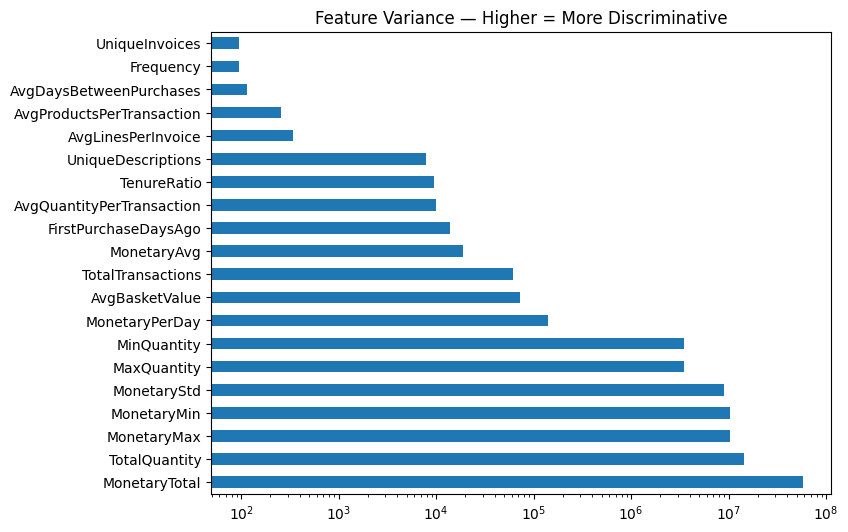

In [43]:
variance = X_train.var().sort_values(ascending=False)
print(variance.head(20))

# Visualize
variance.head(20).plot(kind='barh', figsize=(8,6),logx=True)
plt.title('Feature Variance — Higher = More Discriminative')
plt.show()

TenureRatio                  0.451515
PreferredMonth               0.216333
FavoriteSeason_Automne       0.200045
FirstPurchaseDaysAgo         0.116409
LoyaltyLevel                 0.102985
Frequency                    0.098835
UniqueInvoices               0.096852
TotalTransactions            0.093014
TotalQuantity                0.092035
SpendingCategory             0.085374
UniqueDescriptions           0.081055
MonetaryTotal                0.078526
AvgLinesPerInvoice           0.075681
AvgDaysBetweenPurchases      0.072372
AvgProductsPerTransaction    0.070209
dtype: float64


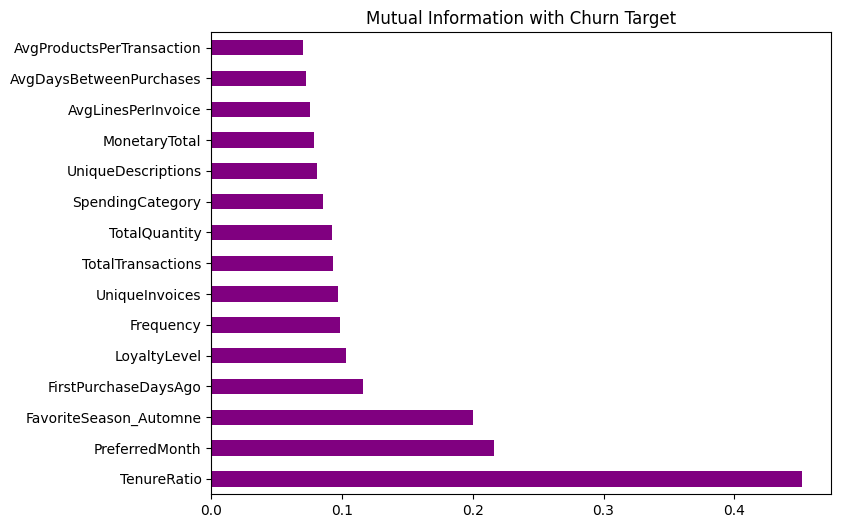

In [44]:
from sklearn.feature_selection import mutual_info_classif

mi = pd.Series(
    mutual_info_classif(X_train, y_train, random_state=42),
    index=X_train.columns
).sort_values(ascending=False)

print(mi.head(15))
mi.head(15).plot(kind='barh', color='purple', figsize=(8,6))
plt.title('Mutual Information with Churn Target')
plt.show()

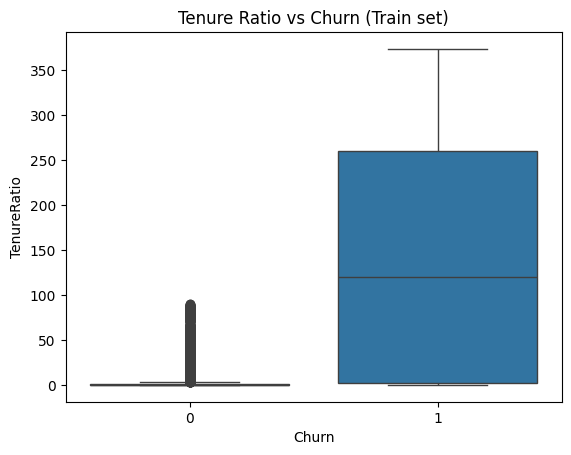

In [45]:
sns.boxplot(x=y_train, y=X_train['TenureRatio'])
plt.title('Tenure Ratio vs Churn (Train set)')
plt.show()

In [46]:
X_train = X_train.drop(columns=['TenureRatio'])
X_test  = X_test.drop(columns=['TenureRatio'])

PreferredMonth             0.203733
FavoriteSeason_Automne     0.194629
FirstPurchaseDaysAgo       0.114252
LoyaltyLevel               0.106805
Frequency                  0.105991
TotalTransactions          0.099475
UniqueInvoices             0.099035
UniqueDescriptions         0.095563
TotalQuantity              0.088216
SpendingCategory           0.086388
MonetaryTotal              0.077387
MonetaryMin                0.075815
AvgLinesPerInvoice         0.074491
ProductsPerTrans           0.067408
AvgDaysBetweenPurchases    0.065130
dtype: float64


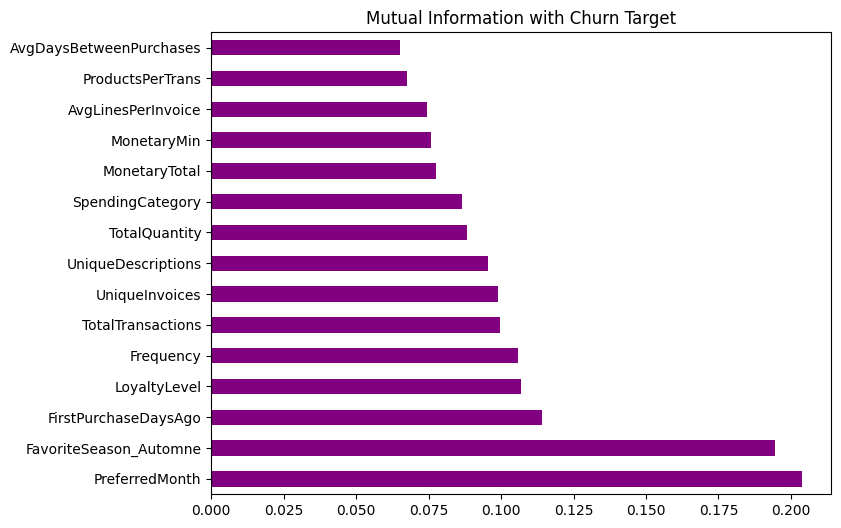

In [47]:
from sklearn.feature_selection import mutual_info_classif

mi = pd.Series(
    mutual_info_classif(X_train, y_train, random_state=42),
    index=X_train.columns
).sort_values(ascending=False)

print(mi.head(15))
mi.head(15).plot(kind='barh', color='purple', figsize=(8,6))
plt.title('Mutual Information with Churn Target')
plt.show()

In [48]:
print(X_train.groupby(y_train)['FirstPurchaseDaysAgo'].mean())

Churn
0    207.992716
1    263.124678
Name: FirstPurchaseDaysAgo, dtype: float64


In [49]:
X_train = X_train.drop(columns=['UniqueCountries'])
X_test  = X_test.drop(columns=['UniqueCountries'])
#almost constant

In [50]:
X_train.shape

(3497, 63)

In [51]:
X_train.to_csv(r"C:\Users\LENOVO\Desktop\project_ml_retail\data\train_test\tree\X_train.csv", index=False)
X_test.to_csv(r"C:\Users\LENOVO\Desktop\project_ml_retail\data\train_test\tree\X_test.csv",  index=False)

VIF: Trees can handles
VIF does NOT improve tree models
👉 Trees are naturally robust to multicollinearity
👉 Focus instead on feature importance or correlation pruning (light)
| Method                | Tree models      | Linear models |
| --------------------- | ---------------- | ------------- |
| VIF                   | ❌ useless        | ✔ important   |
| Correlation filtering | ⚠ optional       | ✔ useful      |
| Feature importance    | ✔ very important | ✔ important   |



🧠 What you should NOT do for trees

❌ StandardScaler (not needed)
❌ VIF analysis
❌ heavy feature elimination
❌ PCA (usually unnecessary)